# Sentiment Analysis

This notebook applies sentiment analysis to the Bitcoin tweet dataset.

Main workflow:
- 1. Load the cleaned topic-modelled dataset.
- 2. Run the VADER sentiment analysis across the full dataset.
- 3. Run RoBERTa sentiment analysis on a stratified monthly sample.
- 4. Compare sentiment distributions overall, over time, by verification status and follower counts.
- 5. Run a statistical test to check whether sentiment differs significantly between topics.
- 6. Export the enriched dataset with topic and sentiment columns.

## 1. Imports and setup

In [2]:
# Core Data Libraries
from pathlib import Path

import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

# Statistical Testing
from scipy.stats import kruskal


#  VADER sentiment analysis
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
# VADER lexicon 
nltk.download("vader_lexicon")

# Optional display settings to make tables easier to inspect
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Folder for notebook outputs
output_folder = Path("outputs_sentiment_analysis")
output_folder.mkdir(parents=True, exist_ok=True)


print("Imports complete.")
print(f"Plots will be saved to: {output_folder}")

Imports complete.
Plots will be saved to: outputs_sentiment_analysis


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/icedspice/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 2. Load the cleaned dataset

The tweet text was pre-cleaned to reduce noise before sentiment and topic analyis. This included removing or detecting common non-content elements such as mentions, URL's, hashtags, leading/trailing whitespace, and repeated promotional spam patterns.  
Spam keywords were identified according to common cryptocurrency spam behaviours, including referral promotions, giveaway language, airdrops, guaranteed profit claims, "pump" or "moonshot" language, investment scam phrases, exchange, exchange referral promotions, NFT promotions and generic engagement farming terms such as "follow me" or "retweet".  
This cleaning step was used to improve the quality of the dataset by reducing tweets that were likely to be promotional, automated, duplicated or unrelated to genuine Bitcoin discussion.

In [5]:
# Input file of produced from previous topic modelling stage
input_file = Path("data/bitcoin_tweet_with_topics.parquet")
# Load the cleaned dataset
df = pd.read_parquet(input_file)
# Make sure the date column is in datetime format before using .dt or resample()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Dataset loaded successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing dates: {df['date'].isna().sum():,}")
print(f"Number of topics: {df['dominant_topic'].nunique()}")

df.head()

Dataset loaded successfully.
Rows: 627,360
Columns: 15
Date range: 2025-03-06 14:43:39+00:00 to 2026-03-02 23:59:53+00:00
Missing dates: 0
Number of topics: 5


,user_name,user_created,user_followers,user_friends,user_verified,date,text,text_clean,hashtags,mentions,account_age_days,dominant_topic,topic_label,topic_strength,topic_confidence
0,Alal,2022-02-25 04:30:38+00:00,17,179,False,2025-03-06 14:43:39+00:00,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,amazing impressed project hopefully event comm...,[BTC],"[mexcresearch, mexc_fans, mexc_updates, alnahy...",1104,2,Crypto projects and future expectations,0.072240,1.000000
1,Bottle🐐,2015-02-19 08:11:45+00:00,527,307,False,2025-03-06 14:44:05+00:00,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,fud sub wan risk buy prices imo,[BTC],"[iamdonaldyusuf, yuzomausman, aproko_doctor]",3667,0,"Buying, selling and trading behaviour",0.027385,0.847849
2,LowCapVillain,2021-12-30 00:19:52+00:00,108,31,False,2025-03-06 14:44:09+00:00,I personally ignore weekend moves and chill wi...,personally ignore weekend moves chill family,[BTC],[],1161,1,Bitcoin as money and store of value,0.003070,0.502805
3,Millennial Wealth,2021-08-26 00:26:37+00:00,24,86,False,2025-03-06 14:44:23+00:00,Move Digital Energy Through Cyber Space. #Bitc...,digital energy cyber space,"[Bitcoin, BTC]",[],1287,1,Bitcoin as money and store of value,0.006987,0.998150
4,Crypto Don,2020-03-19 17:04:42+00:00,180,908,False,2025-03-06 14:46:23+00:00,"1/2 End of shitcoin season, lasted even longer...",end shitcoin season lasted longer expected fro...,"[cronje, frognation, BTC]",[],1812,3,Ethereum and altcoin discussion,0.022690,0.572949


## 3. VADER Sentiment Analyis

VADER is applied to the full dataset because the next phase needs sentiment coverage for every tweet.  
The VADER compound score ranges from -1 to +1:
- Scores closer to +1 are more positive
- Scores closer to -1 are more negative
- Scores near 0 are more neutral or mixed

In [6]:
# Initialise VADER
sia = SentimentIntensityAnalyzer()

# Apply VADER to the cleaned tweet text.
# fillna("") prevents errors if any text values are missing.
df["vader_compound"] =  (
    df["text_clean"]
    .fillna("")
    .astype(str)
    .apply(lambda text: sia.polarity_scores(text)
    ["compound"])
)

def classify_vader_sentiment(compound_score) :
    """
    Convert VADER compound scores into sentiment classes
    Common VADER thresholds:
        - compound >= 0.5 -> positive
        - compound <= -0.5 -> negative
        - otherwise        -> neutral
    """
    
    if compound_score >= 0.05 :
        return "positive"
    elif compound_score <= -0.05 :
        return "negative"
    else:
        return "neutral"

# Create sentiment category for from compound score
df["vader_sentiment"] = df["vader_compound"].apply(classify_vader_sentiment)

print("VADER sentiment analysis complete.")
print(f"Rows scored: {df['vader_compound'].notna().sum():,}")
print("VADER sentiment counts:")
print(df["vader_sentiment"].value_counts())

df[["text_clean", "vader_compound", "vader_sentiment"]].head()

VADER sentiment analysis complete.
Rows scored: 627,360
VADER sentiment counts:
vader_sentiment
positive    268288
neutral     210767
negative    148305
Name: count, dtype: int64


,text_clean,vader_compound,vader_sentiment
0,amazing impressed project hopefully event comm...,0.9269,positive
1,fud sub wan risk buy prices imo,-0.4939,negative
2,personally ignore weekend moves chill family,-0.3612,negative
3,digital energy cyber space,0.2732,positive
4,end shitcoin season lasted longer expected fro...,-0.6705,negative


## 4. RoBERTa sentiment analysis

RoBERTa is more computationally expensive than VADER, so it is kept to a sample.  
This sample is stratified by month so that the model does not overrepresent only the busiest months.  

Install dependencies first if needed:  
```python
pip install transformers torch
```

In [7]:
from transformers import pipeline
import torch

# Automatically uses GPU if available, otherwise falls back to CPU
device = 0 if torch.cuda.is_available() else -1

if (device == 0) :
    print("Using GPU for RoBERTA:", torch.cuda.get_device_name(0))
else :
    print("Using CPU for RoBERTa. This may take longer.")

# Load the pretrained Twitter RoBERTa sentiment model
roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    truncation=True,
    max_length=512
)

# Make a copy for monthly stratified sampling
sample_source_df = df.copy()

# Create month column for stratified sampling
sample_source_df["month"] = sample_source_df["date"].dt.to_period("M")

# Drop rows where month could not be created 
sample_source_df = sample_source_df.dropna(subset=["month"])

# Target size for RoBERTa sample
target_sample_size = 20000

# Calculate an equal sample size per month
num_months = sample_source_df["month"].nunique()
sample_per_month = target_sample_size // num_months

print(f"Months available: {num_months}")
print(f"Target sample size: {target_sample_size:,}")
print(f"Sample per month: {sample_per_month:,}")

# Sample from every month
# min(len(x), sample_per_month) avoids errors when a month has fewer tweets than the target
roberta_sample_df = (
    sample_source_df
    .groupby("month", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), sample_per_month), random_state=41))
    .copy()
)

print(f"Actual RoBERTa sample size: {len(roberta_sample_df):,}")
print("Sample count by month:")
print(roberta_sample_df["month"].value_counts().sort_index())


# Convert text_clean column to a list for model input
sample_tweets = roberta_sample_df["text_clean"].fillna("").astype(str).tolist()

print("Running RoBERTa sentiment model...")

# Run RoBERTa on the comments
roberta_results = roberta(
    sample_tweets, 
    batch_size=32,
    truncation=True,
    max_length=512
)

# Store RoBERTa outputs
roberta_sample_df["roberta_score"] = [result["score"] for result in roberta_results]
roberta_sample_df["roberta_sentiment"] = [result["label"] for result in roberta_results]

print("RoBERTa sentiment analysis complete.")
print("RoBERTa sentiment counts:")
print(roberta_sample_df["roberta_sentiment"].value_counts())

roberta_sample_df[["text_clean", "roberta_sentiment", "roberta_score"]].head()

Using CPU for RoBERTa. This may take longer.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_64717/92315885.py:26: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sample_source_df["month"] = sample_source_df["date"].dt.to_period("M")
/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_64717/92315885.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupi

Months available: 13
Target sample size: 20,000
Sample per month: 1,538
Actual RoBERTa sample size: 19,361
Sample count by month:
month
2025-03    1538
2025-04    1538
2025-05    1538
2025-06    1538
2025-07    1538
2025-08    1538
2025-09    1538
2025-10    1538
2025-11    1538
2025-12    1538
2026-01    1538
2026-02    1538
2026-03     905
Freq: M, Name: count, dtype: int64
Running RoBERTa sentiment model...
RoBERTa sentiment analysis complete.
RoBERTa sentiment counts:
roberta_sentiment
neutral     12961
negative     3580
positive     2820
Name: count, dtype: int64


,text_clean,roberta_sentiment,roberta_score
12300,moron professional winklevos brothers gods num...,neutral,0.617258
26117,check nct token recently listed coinbase polys...,neutral,0.643485
2892,joinning accomulating yld main strategy order ...,neutral,0.673469
14182,satoshi nakamoto dear creator transfer holding...,neutral,0.764013
25338,strongest bullish signal flashed trend reverse...,positive,0.754066


## 5. RoBERTa sentiment distribution

In [9]:
# Convert to percentages for easier comparison
roberta_counts = (
    roberta_sample_df["roberta_sentiment"]
        .value_counts(normalize=True)
        .mul(100)
)

print("RoBERTa sentiment distribution (%):")
print(roberta_counts.round(2))

RoBERTa sentiment distribution (%):
roberta_sentiment
neutral     66.94
negative    18.49
positive    14.57
Name: proportion, dtype: float64


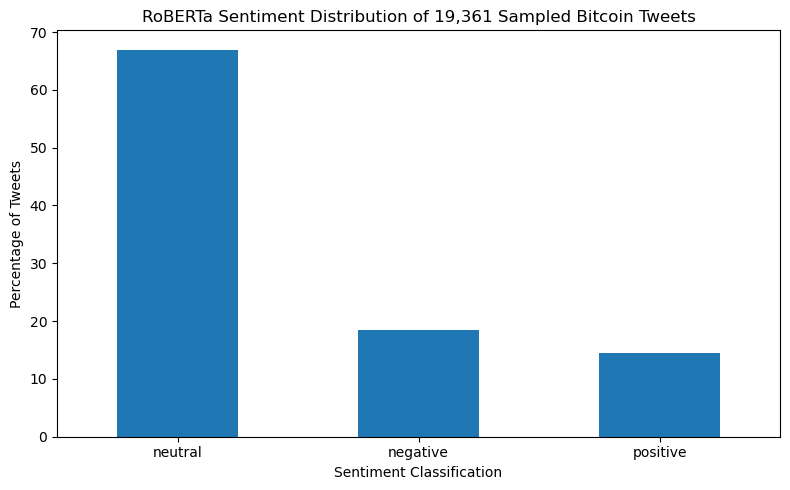

In [10]:
plt.figure(figsize=(8,5))

roberta_counts.plot(kind="bar")

plt.title(f"RoBERTa Sentiment Distribution of {len(roberta_sample_df):,} Sampled Bitcoin Tweets")
plt.xlabel("Sentiment Classification")
plt.ylabel("Percentage of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(output_folder/ "roBERTa_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. VADER sentiment distribution

In [7]:
# Convert VADER sentiment counts to percentages 
vader_counts = (
    df["vader_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
)

print("VADER sentiment distribution (%):")
print(vader_counts.round(2))

VADER sentiment distribution (%):
vader_sentiment
positive    42.76
neutral     33.60
negative    23.64
Name: proportion, dtype: float64


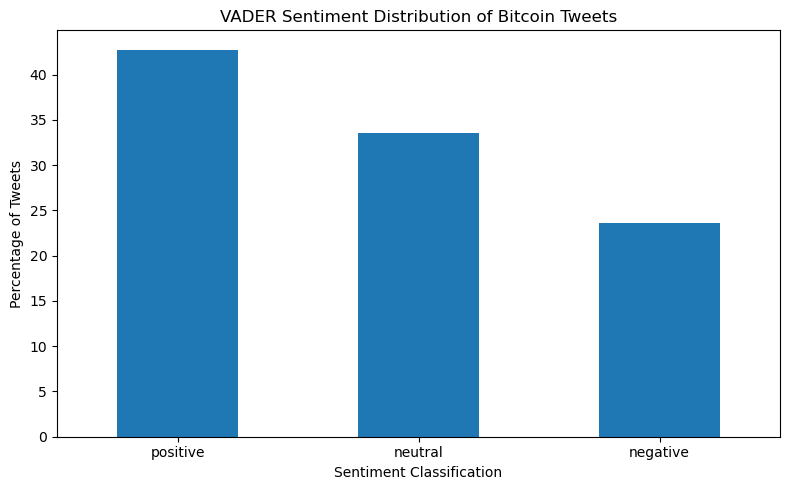

In [8]:
plt.figure(figsize=(8,5))
vader_counts.plot(kind="bar")

plt.title("VADER Sentiment Distribution of Bitcoin Tweets")
plt.xlabel("Sentiment Classification")
plt.ylabel("Percentage of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(output_folder/ "VADER_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. VADER sentiment distribution by month

Monthly VADER sentiment distribution


/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_9929/2749438560.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M")


vader_sentiment,negative,neutral,positive
month,,,
2025-03,7289,11959,15969
2025-04,10213,15989,21689
2025-05,15459,19237,24599
2025-06,22059,26975,33046
2025-07,22484,32107,41969


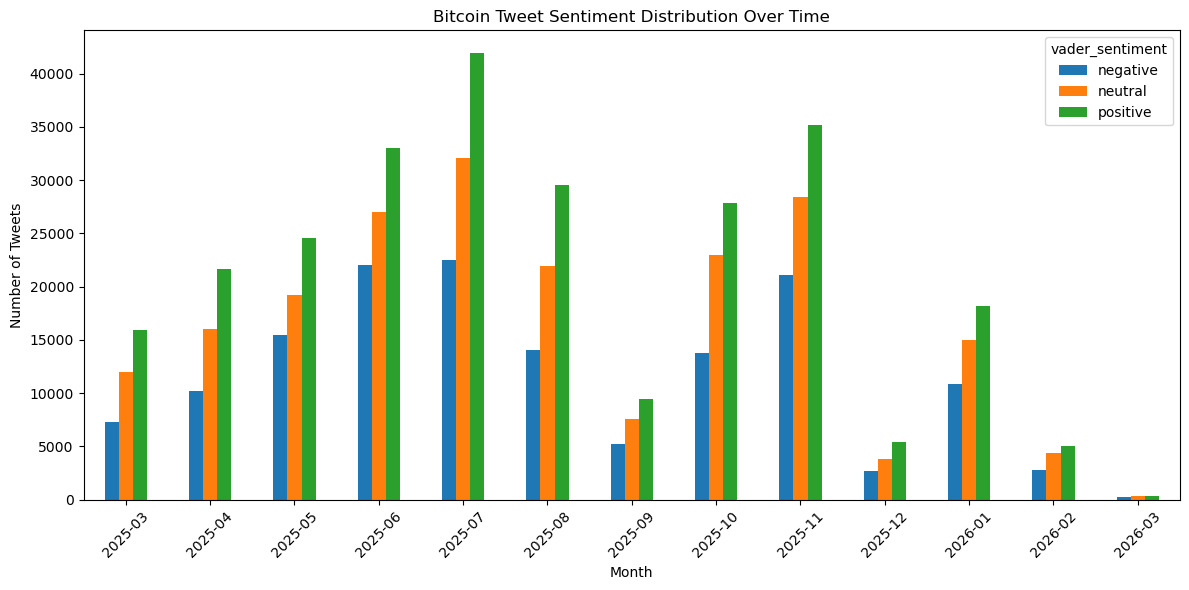

In [9]:
# Add year-month column for time based grouping 
df["month"] = df["date"].dt.to_period("M")

# Count positive, neutral and negative tweets for each month
monthly_vader_distribution = (
    df
    .groupby(["month", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
)

print("Monthly VADER sentiment distribution")
display(monthly_vader_distribution.head())

monthly_vader_distribution.plot(kind="bar", figsize=(12,6))

plt.title("Bitcoin Tweet Sentiment Distribution Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_folder/ "VADER_sentiment_distribution_monthly.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Average VADER sentiment over time

Average monthly VADER sentiment:


date
2025-03-31 00:00:00+00:00    0.141359
2025-04-30 00:00:00+00:00    0.145003
2025-05-31 00:00:00+00:00    0.089161
2025-06-30 00:00:00+00:00    0.079576
2025-07-31 00:00:00+00:00    0.119476
Freq: ME, Name: vader_compound, dtype: float64

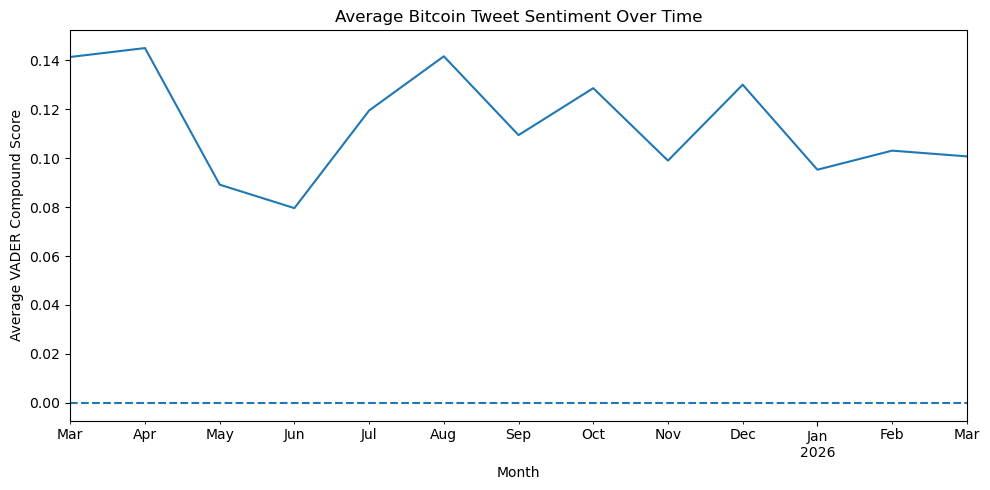

In [10]:
# Monthly mean of VADER compound score
monthly_vader = (
    df
    .set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)

print("Average monthly VADER sentiment:")
display(monthly_vader.head())

monthly_vader.plot(figsize=(10,5))

plt.title("Average Bitcoin Tweet Sentiment Over Time")
plt.xlabel("Month")
plt.ylabel("Average VADER Compound Score")
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.savefig(output_folder/ "VADER_avg_compound_score.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Sentiment by user verification status

Number of tweets from verified users: 4,743
Number of tweets from unverified users: 622,617


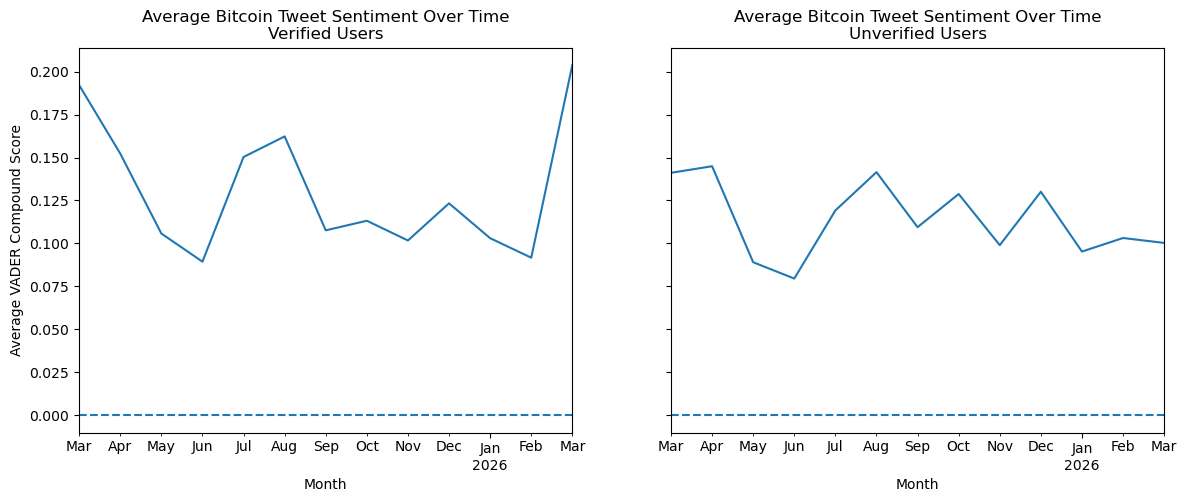

In [11]:
# Split dataset by verification status
verified_df = df[df["user_verified"] == True].copy()
unverified_df = df[df["user_verified"] == False].copy()

print(f"Number of tweets from verified users: {len(verified_df):,}")
print(f"Number of tweets from unverified users: {len(unverified_df):,}")


# Monthly average sentiment for verified users
verified_monthly_vader = (
    verified_df
    .set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)
# Monthly average sentiment for unverified users
unverified_monthly_vader = (
    unverified_df
    .set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)

fig, axes = plt.subplots(1,2, figsize=(14,5), sharey=True)

verified_monthly_vader.plot(ax=axes[0])
axes[0].set_title("Average Bitcoin Tweet Sentiment Over Time\nVerified Users")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average VADER Compound Score")
axes[0].axhline(0, linestyle="--")

unverified_monthly_vader.plot(ax=axes[1])
axes[1].set_title("Average Bitcoin Tweet Sentiment Over Time\nUnverified Users")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average VADER Compound Score")
axes[1].axhline(0, linestyle="--")

fig.savefig(
    output_folder / "verified_vs_unverified_vader_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

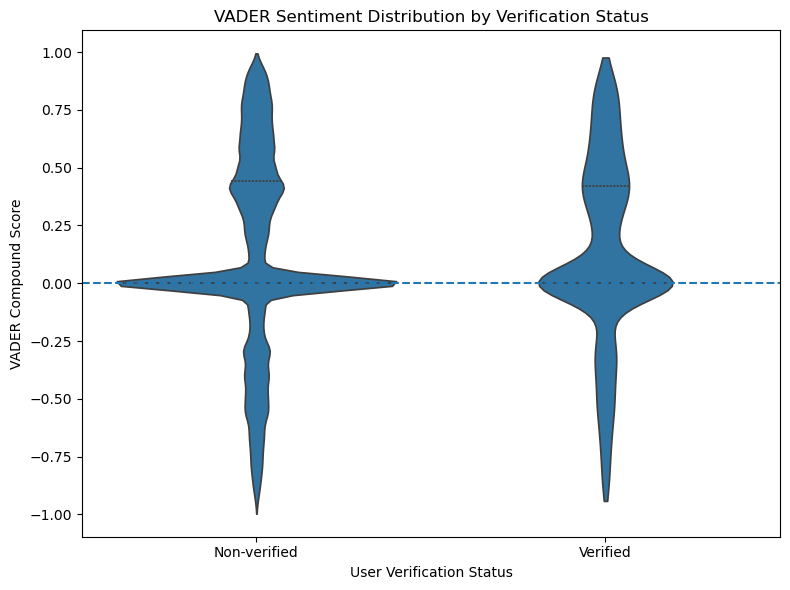

In [12]:
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df.assign(
        verified_label=df["user_verified"].map({
            True: "Verified",
            False: "Non-verified"
        })
    ),
    x="verified_label",
    y="vader_compound",
    inner="quartile",
    cut=0
)

plt.title("VADER Sentiment Distribution by Verification Status")
plt.xlabel("User Verification Status")
plt.ylabel("VADER Compound Score")
plt.axhline(0, linestyle="--")
plt.tight_layout()

plt.savefig(output_folder / "VADER_violin_verified_status.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Sentiment distribution by follower tier

In [13]:
# Work on a copy so follower-tier transformations do not affect df
follower_df = df.copy()

# Ensure user_followers is numeric
# Invalid values become NaN rather than causing the code to crash
follower_df["user_followers"] = pd.to_numeric(
    follower_df["user_followers"],
    errors="coerce"
)

# Define follower count ranges 
bins = [0, 1000, 10000, 50000, 500000, 1000000, float("inf")]

# Labels for each follower tier
labels = [
    "Under 1k",
    "Nano: 1k - 10k",
    "Micro: 10k - 50k",
    "Mid-tier: 50k - 500k",
    "Macro: 500k - 1M",
    "Mega: 1M+"
]

# Assign each user to a follower tier
follower_df["follower_tier"] = pd.cut(
    follower_df["user_followers"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count each VADER sentiment category within each follower tier
tier_counts = (
    follower_df
    .groupby(["follower_tier", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages within each follower tier
tier_percent = (
    tier_counts
    .div(tier_counts.sum(axis=1), axis=0)
    .mul(100)
)

print("Follower tier counts:")
display(tier_counts)

print("Follower tier percentages:")
display(tier_percent.round(2))

Follower tier counts:


/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_9929/1880094416.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["follower_tier", "vader_sentiment"])


vader_sentiment,negative,neutral,positive
follower_tier,,,
Under 1k,117091,166480,205117
Nano: 1k - 10k,24192,33450,49446
Micro: 10k - 50k,5006,7662,10158
Mid-tier: 50k - 500k,1925,2952,3355
Macro: 500k - 1M,62,132,118
Mega: 1M+,29,91,94


Follower tier percentages:


vader_sentiment,negative,neutral,positive
follower_tier,,,
Under 1k,23.96,34.07,41.97
Nano: 1k - 10k,22.59,31.24,46.17
Micro: 10k - 50k,21.93,33.57,44.50
Mid-tier: 50k - 500k,23.38,35.86,40.76
Macro: 500k - 1M,19.87,42.31,37.82
Mega: 1M+,13.55,42.52,43.93


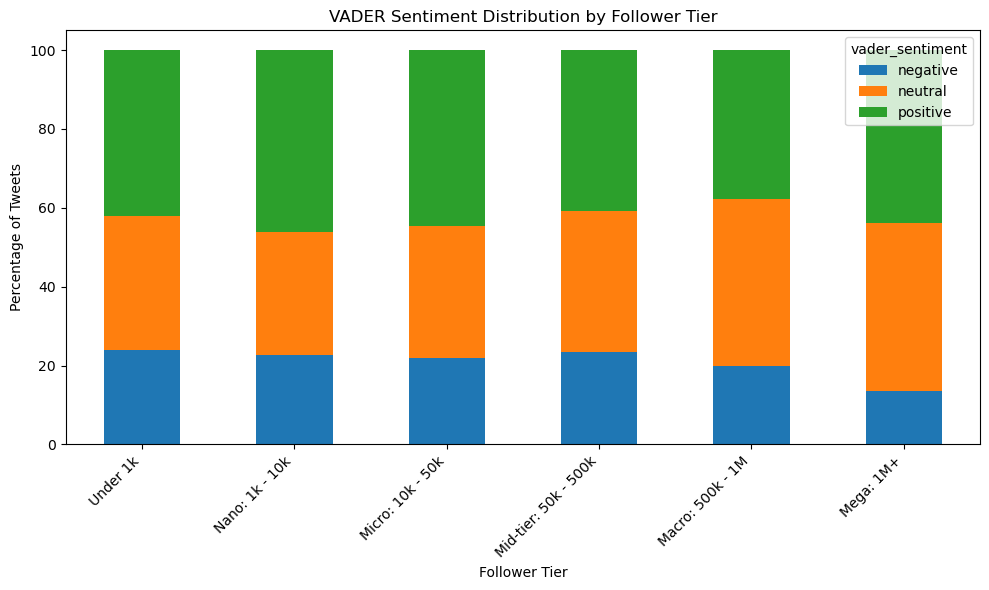

In [14]:
tier_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)
plt.title("VADER Sentiment Distribution by Follower Tier")
plt.xlabel("Follower Tier")
plt.ylabel("Percentage of Tweets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_folder/ "VADER_sentiment_distribution_followers.png", dpi=300, bbox_inches="tight")
plt.show()

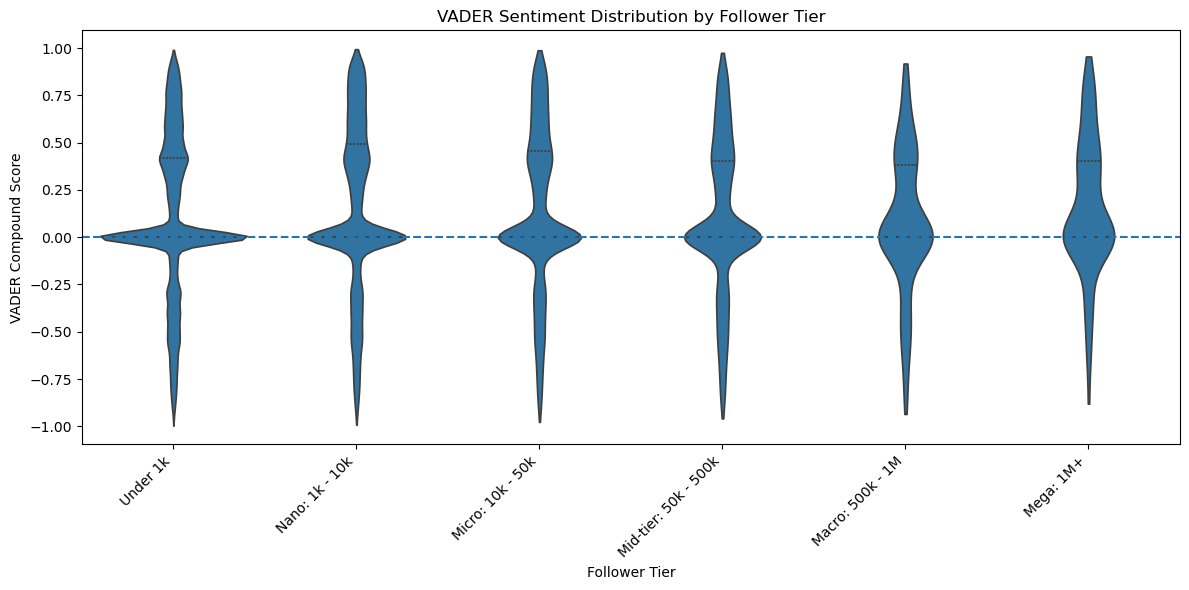

In [15]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=follower_df,
    x="follower_tier",
    y="vader_compound",
    inner="quartile",
    cut=0
)

plt.title("VADER Sentiment Distribution by Follower Tier")
plt.xlabel("Follower Tier")
plt.ylabel("VADER Compound Score")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(output_folder / "VADER_violin_follower_tier.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Average VADER sentiment by follower tier

Average VADER compound score by follower tier:


/var/folders/bj/qwsyzs8512v0xnhhqlmd255r0000gn/T/ipykernel_9929/644798553.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("follower_tier")["vader_compound"]


,follower_tier,vader_compound
0,Under 1k,0.104955
1,Nano: 1k - 10k,0.146043
2,Micro: 10k - 50k,0.133133
3,Mid-tier: 50k - 500k,0.094166
4,Macro: 500k - 1M,0.078058
5,Mega: 1M+,0.155310


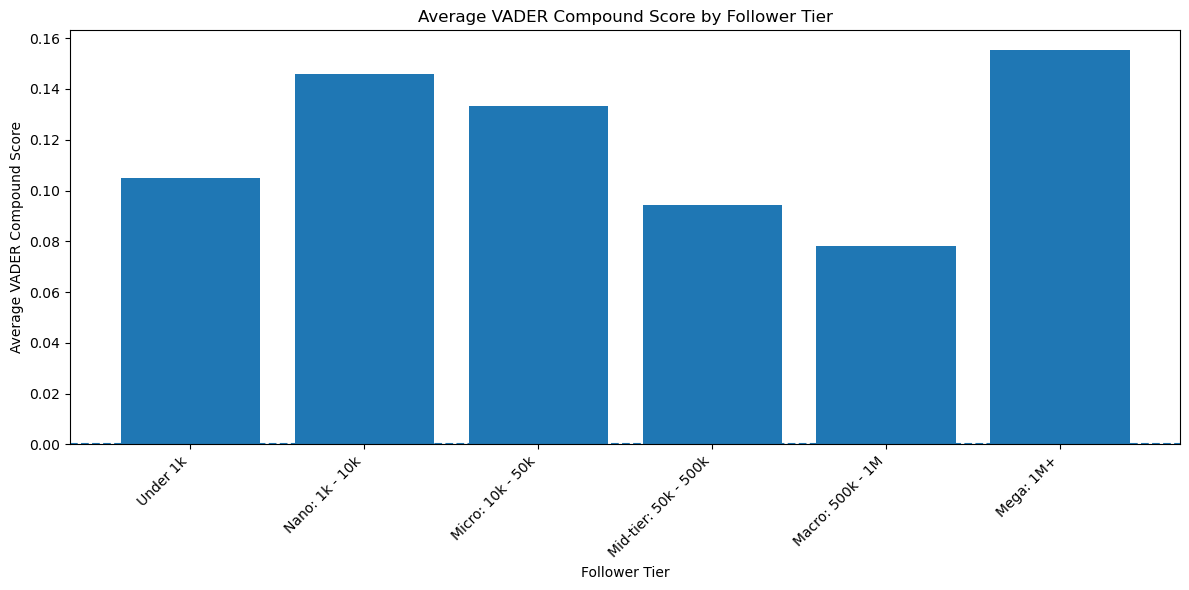

In [16]:
avg_vader_by_tier = (
    follower_df
    .groupby("follower_tier")["vader_compound"]
    .mean()
    .reset_index()
)

print("Average VADER compound score by follower tier:")
display(avg_vader_by_tier)

plt.figure(figsize=(12,6))

plt.bar(
    avg_vader_by_tier["follower_tier"].astype(str),
    avg_vader_by_tier["vader_compound"]
)

plt.title("Average VADER Compound Score by Follower Tier")
plt.xlabel("Follower Tier")
plt.ylabel("Average VADER Compound Score")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_folder/ "VADER_avg_compound_score_follower.png", dpi=300, bbox_inches="tight")
plt.show()

## Sentiment distribution by topic

The topic number alone can be hard to interpret, so this creates a readable topic label that combines:  
- the numeric topic id
- the topic label

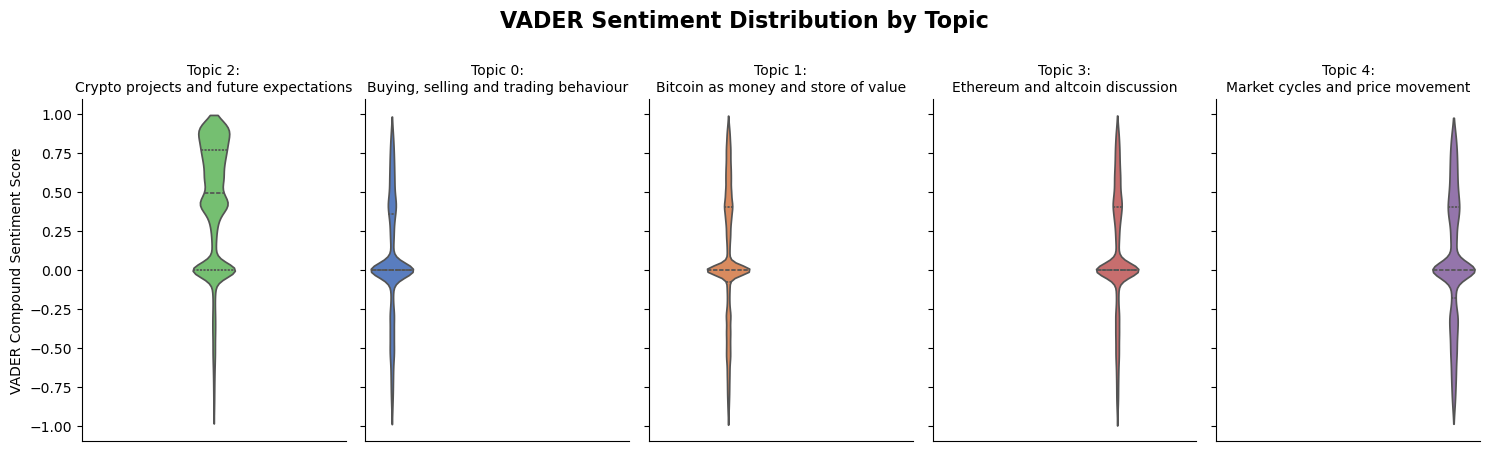

In [17]:
df["topic_display"] = (
    "Topic " + df["dominant_topic"].astype(str) + ":\n" + df["topic_label"].astype(str)
)

g = sns.catplot(
    data=df,
    x="dominant_topic",      
    y="vader_compound",
    col="topic_display",     # Creates a separate subgraph for each unique topic label
    hue="dominant_topic",    
    kind="violin",
    inner="quartile",
    cut=0,
    palette="muted",         
    legend=False,            
    sharey=True,             # Forces all subplots to share the exact same Y-axis
    height=5,                
    aspect=0.6,              
)

g.set_titles("{col_name}")   
g.set_axis_labels("", "VADER Compound Sentiment Score") 
g.set(xticks=[])             

plt.subplots_adjust(top=0.8)
g.fig.suptitle("VADER Sentiment Distribution by Topic", fontsize=16, weight="bold", y=0.98)

plt.show()

## Average VADER score per topic

Average VADER score per topic:


,dominant_topic,topic_label,topic_display,vader_compound
2,2,Crypto projects and future expectations,Topic 2:\nCrypto projects and future expectations,0.429400
3,3,Ethereum and altcoin discussion,Topic 3:\nEthereum and altcoin discussion,0.105160
1,1,Bitcoin as money and store of value,Topic 1:\nBitcoin as money and store of value,0.087409
0,0,"Buying, selling and trading behaviour","Topic 0:\nBuying, selling and trading behaviour",0.065949
4,4,Market cycles and price movement,Topic 4:\nMarket cycles and price movement,0.061742


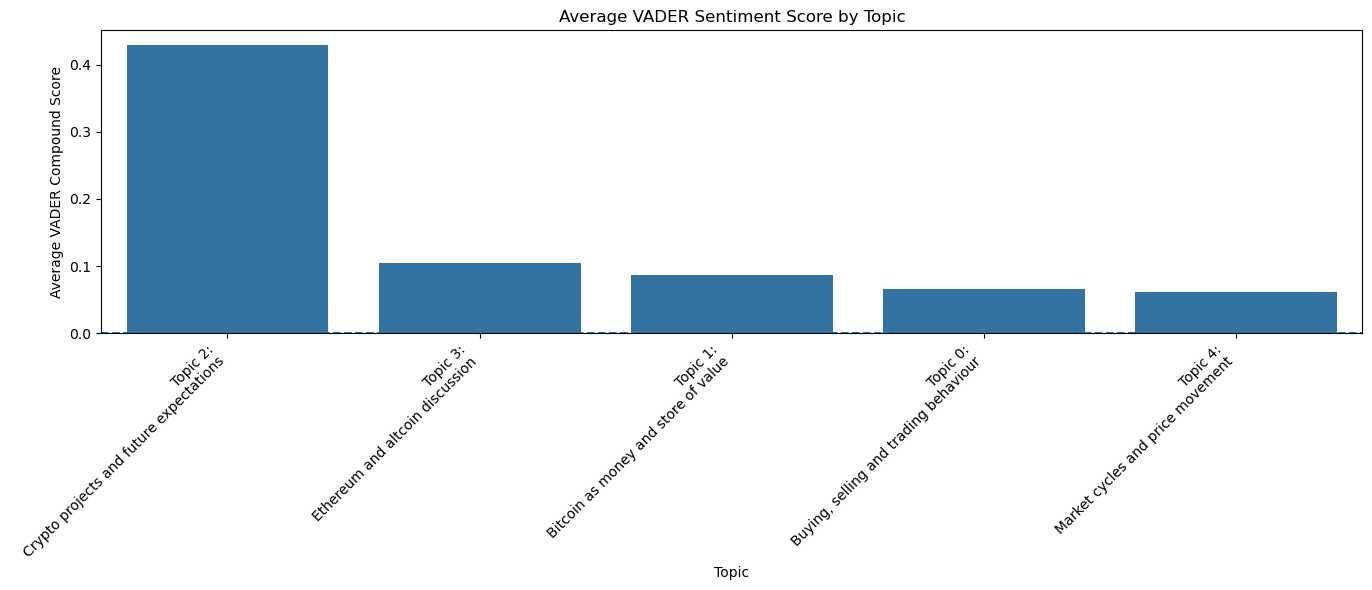

In [18]:
# Calculate average VADER compound score for each topic
topic_avg_vader = (
    df
    .groupby(["dominant_topic", "topic_label", "topic_display"])["vader_compound"]
    .mean()
    .reset_index()
    .sort_values("vader_compound", ascending=False)
)

print("Average VADER score per topic:")
display(topic_avg_vader)

plt.figure(figsize=(14,6))

sns.barplot(
    data=topic_avg_vader,
    x="topic_display",
    y="vader_compound"
)

plt.title("Average VADER Sentiment Score by Topic")
plt.xlabel("Topic")
plt.ylabel("Average VADER Compound Score")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_folder/ "VADER_avg_compound_score_topic.png", dpi=300, bbox_inches="tight")
plt.show()

## Statistical test: sentiment differences between topics

A Kruskal-Wallis test is used because VADER scores are unlikely to be normally distributed.  
    This test checks whether at least one topic has significantly different sentiment distribution from the others.  
    - `p < 0.05`: sentiment differs significantly between topics.  
    - `p >= 0.05`: there is not enough evidence to say sentiment differs between topics.

In [19]:
# Creates one list of VADER score per topic
topic_groups = [
    group["vader_compound"].dropna()
    for _, group in df.groupby("topic_display")
]

# Run Kruskal-Wallis test across topic groups
kruskal_result = kruskal(*topic_groups)

print("Kruskal-Wallis Test")
print("H-statistic:", kruskal_result.statistic)
print("p-value:", kruskal_result.pvalue)


if kruskal_result.pvalue < 0.05:
    print("Conclusion: There is a statistically significant difference in sentiment between topics.")
else:
    print("Conclusion: There is no statistically significant difference in sentiment between topics.")

Kruskal-Wallis Test
H-statistic: 29319.819232018832
p-value: 0.0
Conclusion: There is a statistically significant difference in sentiment between topics.


## 15. Export enriched dataset with Sentiment

In [18]:
# Copy the final enriched dataframe before export
bitcoin_tweet_with_topics_sentiment = df.copy()

# Output file path
output_file = Path("data/bitcoin_tweet_with_topics_sentiment.parquet")

# Create the data folder if it does not already exist
output_file.parent.mkdir(parents=True, exist_ok=True)

# Export to parquet
bitcoin_tweet_with_topics_sentiment.to_parquet(output_file, index=False)

print("Export complete.")
print("Saved file:", output_file)
print("Rows exported:", len(bitcoin_tweet_with_topics_sentiment))
print("Columns exported:")
print(bitcoin_tweet_with_topics_sentiment.columns.tolist())

Export complete.
Saved file: data\bitcoin_tweet_with_topics_sentiment.parquet
Rows exported: 627360
Columns exported:
['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'text_clean', 'hashtags', 'mentions', 'account_age_days', 'dominant_topic', 'topic_label', 'topic_strength', 'topic_confidence', 'vader_compound', 'vader_sentiment', 'month', 'topic_display']
